# Partial Differential Equations

examples

In [1]:
import numpy as np
from fractions import Fraction
from functools import reduce, lru_cache, partial

from scipy import linalg as la
import scipy.optimize as opt
from scipy import special, interpolate, integrate
import matplotlib.pyplot as plt
from numpy.polynomial import Polynomial
np.set_printoptions(suppress=True, precision=6)

def sign(x):
    s = np.sign(x)
    return s if s else 1

In [2]:
# 11.8
A = [
    [4, -1, -1, 0],
    [-1, 4, 0, -1],
    [-1, 0, 4, -1],
    [0, -1, -1, 4],
]

b = [0, 0, 1, 1]


def jacobi(A, b, x0, tol=1e-3, n=1000):
    xold = np.array(x0)
    xnew = np.zeros_like(x0)
    history, m, A = [xold.tolist()], len(b), np.array(A)
    for _ in range(n):
        for i in range(m):
            xnew[i] = b[i] - (xold[np.arange(m) != i] @ A[i, np.arange(m) != i])
            xnew[i] /= A[i, i]
        history.append(xnew.tolist())
        if la.norm(xnew - xold) < tol:
            print(xold, xnew, xnew - xold, la.norm(xnew - xold), tol)
            break
        xold[:] = xnew[:]
    return np.array(history)


jacobi(A, [0, 0, 1, 1], np.zeros(4)).round(3)


[0.124023 0.124023 0.374023 0.374023] [0.124512 0.124512 0.374512 0.374512] [0.000488 0.000488 0.000488 0.000488] 0.0009765625 0.001


array([[0.   , 0.   , 0.   , 0.   ],
       [0.   , 0.   , 0.25 , 0.25 ],
       [0.062, 0.062, 0.312, 0.312],
       [0.094, 0.094, 0.344, 0.344],
       [0.109, 0.109, 0.359, 0.359],
       [0.117, 0.117, 0.367, 0.367],
       [0.121, 0.121, 0.371, 0.371],
       [0.123, 0.123, 0.373, 0.373],
       [0.124, 0.124, 0.374, 0.374],
       [0.125, 0.125, 0.375, 0.375]])

In [3]:
def gauss_seidel(A, b, x0, tol=1e-3, n=1000, step=1):
    x = np.array(x0)
    history, m, A = [x.tolist()], len(b), np.array(A)
    for _ in range(n):
        r = 0
        for i in range(0, m, step):
            v = b[i] - (x[np.arange(m) != i] @ A[i, np.arange(m) != i])
            v /= A[i, i]
            r += (x[i] - v) ** 2
            x[i] = v

        history.append(x.tolist())
        if np.sqrt(r) < tol:
            break
    return np.array(history)


gauss_seidel(A, b, np.zeros(4)).round(3)

array([[0.   , 0.   , 0.   , 0.   ],
       [0.   , 0.   , 0.25 , 0.312],
       [0.062, 0.094, 0.344, 0.359],
       [0.109, 0.117, 0.367, 0.371],
       [0.121, 0.123, 0.373, 0.374],
       [0.124, 0.125, 0.375, 0.375],
       [0.125, 0.125, 0.375, 0.375]])

In [4]:
# caution w only for this problem
def sor(A, b, x0, tol=1e-3, n=1000, w=1.072):
    x = np.array(x0)
    history, m, A = [x.tolist()], len(b), np.array(A)
    for _ in range(n):
        r = 0
        for i in range(m):
            v = b[i] - (x[np.arange(m) != i] @ A[i, np.arange(m) != i])
            v /= A[i, i]
            r += (w * (v - x[i])) ** 2
            x[i] += w * (v - x[i])

        history.append(x.tolist())
        if np.sqrt(r) < tol:
            break
    return np.array(history)


sor(A, b, np.zeros(4)).round(3)

array([[0.   , 0.   , 0.   , 0.   ],
       [0.   , 0.   , 0.268, 0.34 ],
       [0.072, 0.11 , 0.359, 0.369],
       [0.121, 0.123, 0.373, 0.375],
       [0.124, 0.125, 0.375, 0.375],
       [0.125, 0.125, 0.375, 0.375]])

In [5]:
def jacobi_conjugate_gradient(A, b, x0, tol=1e-3, n=1000):
    x = np.array(x0)
    history, A = [x.tolist()], np.array(A)
    m = 1 / np.diag(A)

    r = b - A @ x
    s = m * r

    for _ in range(n):
        a_s = A @ s
        a = (r @ (m * r)) / (s @ a_s)
        x += a * s
        rnew = r - a * a_s
        beta = (rnew @ (m * rnew)) / (r @ (m * r))
        s = m * rnew + beta * s
        r = rnew

        history.append(x.tolist())
        if la.norm(r) < tol:
            break
    return np.array(history)


jacobi_conjugate_gradient(A, b, np.zeros(4)).round(3)

array([[0.   , 0.   , 0.   , 0.   ],
       [0.   , 0.   , 0.333, 0.333],
       [0.125, 0.125, 0.375, 0.375]])

computer problems

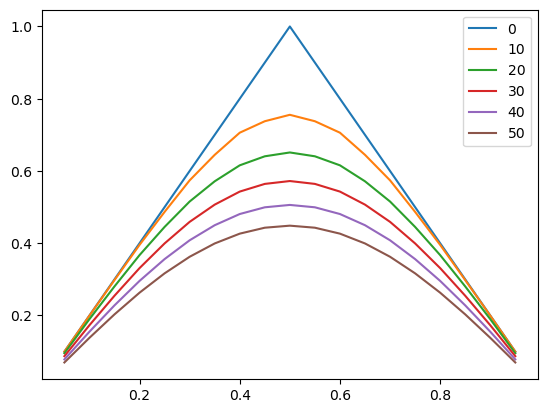

In [6]:
# 11.1
# (a)
def f(y, ynew, dx, dt):
    lam = dt / dx ** 2
    n = len(y)
    for i in range(n):
        v = -2 * y[i]
        if i + 1 < n:
            v += y[i+1]
        if i - 1 >= 0:
            v += y[i-1]
        ynew[i] = y[i] + lam * v


def g(x):
    return np.where(x <= .5, 2 * x, 2 - 2 * x)


def parabolic_full(f, g, x, t):
    dx = x[1] - x[0] # uniform spacing
    dt = t[1] - t[0]

    ys = np.zeros((len(t), len(x)))
    ys[0] = g(x)
    
    for i in range(1, len(t)):
        f(ys[i-1], ys[i], dx, dt)

    return ys

x = np.linspace(0, 1, 21)[1:-1]
t = np.linspace(0, .06, 51)
y = parabolic_full(f, g, x, t)
for i in range(0, 51, 10):
    plt.plot(x, y[i], label=i)
plt.legend()

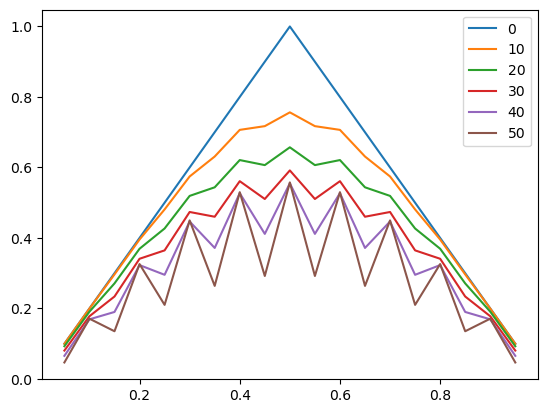

In [7]:
# (b)
t = np.linspace(0, .0013 * 50, 51)
y = parabolic_full(f, g, x, t)
for i in range(0, 51, 10):
    plt.plot(x, y[i], label=i)
plt.legend()

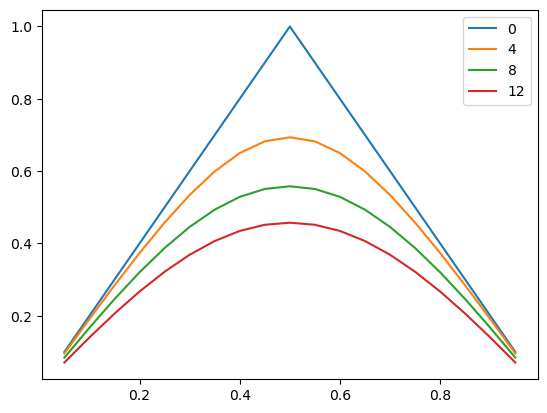

In [8]:
# (c)
def f(y, ynew, dx, dt):
    lam = dt / dx ** 2
    n = len(y)
    A = (1 + 2 * lam) * np.eye(n) - lam * np.diag(np.ones(n-1), -1) - lam * np.diag(np.ones(n-1), 1)
    ynew[:] = la.solve(A, y)[:]


t = np.linspace(0, .005 * 12, 13)
ys = parabolic_full(f, g, x, t)
for i in range(0, 13, 4):
    plt.plot(x, ys[i], label=i)
plt.legend()

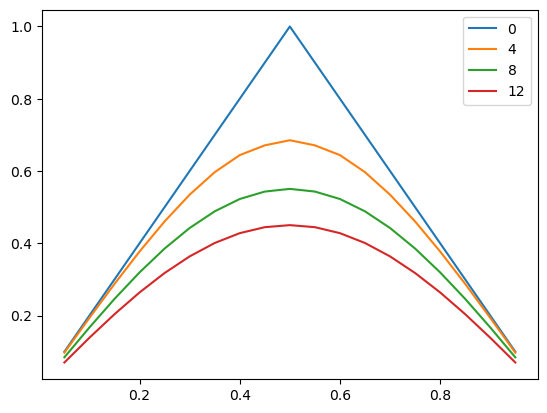

In [9]:
# (d)
def shift_down(y):
    return np.concatenate([y[1:], [0]])


def shift_up(y):
    return np.concatenate([[0], y[:-1]])


def f(y, ynew, dx, dt):
    lam = dt / dx ** 2
    n = len(y)
    A = (1 + lam) * np.eye(n) - lam / 2 * np.diag(np.ones(n-1), -1) - lam / 2 * np.diag(np.ones(n-1), 1)
    b = (1 - lam) * y + lam / 2 * shift_down(y) + lam / 2 * shift_up(y)
    ynew[:] = la.solve(A, b)[:]

ys = parabolic_full(f, g, x, t)
for i in range(0, 13, 4):
    plt.plot(x, ys[i], label=i)
plt.legend()

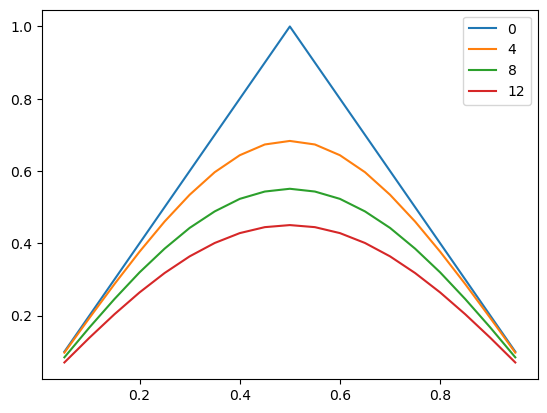

In [10]:
# (e)
def f(t, y, dx, dt, ybegin, yend):
    lam = 1 / dx ** 2
    n = len(y)
    return (lam * (-2 * np.eye(n) + np.diag(np.ones(n-1), -1) + np.diag(np.ones(n-1), 1))) @ y


def method_of_lines(f, g, x, t, ybegin=lambda t:0, yend=lambda t:0):
    n, dx, dt = len(x), x[1] - x[0], t[1] - t[0]
    return integrate.solve_ivp(partial(f, dx=dx, dt=dt, ybegin=ybegin, yend=yend), t_span=[t[0], t[-1]], y0=g(x), t_eval=t).y[:n]


t = np.linspace(0, .005 * 12, 13)
y = method_of_lines(f, g, x, t)
for i in range(0, 13, 4):
    plt.plot(x, y[:, i], label=i)
plt.legend()

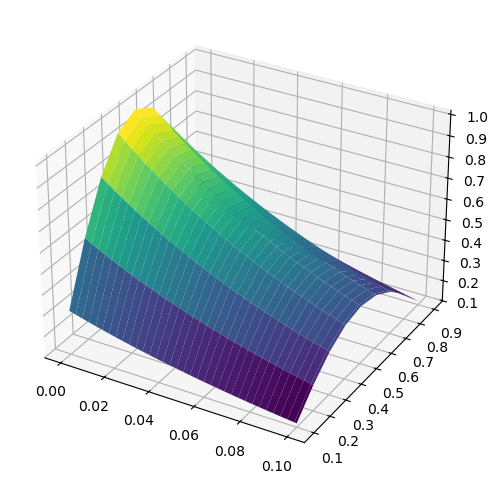

In [11]:
# 11.2
# (a)
def f(t, y, dx, dt, ybegin, yend):
    lam = 1 / dx ** 2
    n = len(y)
    return (lam * (-2 * np.eye(n) + np.diag(np.ones(n-1), -1) + np.diag(np.ones(n-1), 1))) @ y

def g(x):
    return np.sin(np.pi * x)

x = np.linspace(0, 1, 11)[1:-1]
t = np.linspace(0, .001 * 100, 101)

y = method_of_lines(f, g, x, t)

def plot_3d(t, x, y):
    T, X = np.meshgrid(t, x)
    y = y(T, X) if callable(y) else y
    fig = plt.figure(figsize=(8, 6))
    ax = fig.add_subplot(111, projection='3d')
    ax.plot_surface(T, X, y, cmap='viridis', edgecolor='none')

plot_3d(t, x, y)

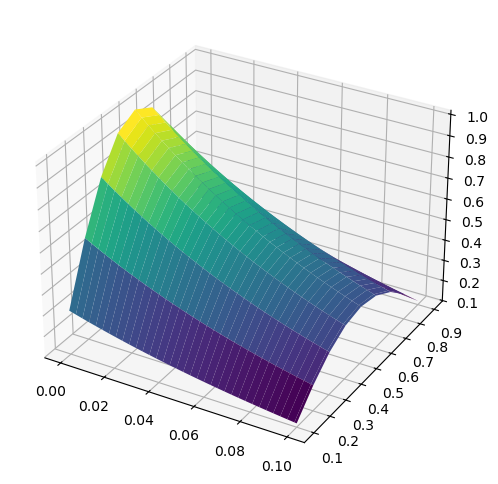

In [12]:
def h(t, x):
    return np.exp(- np.pi ** 2 * t) * np.sin(np.pi * x)


plot_3d(t, x, h)

2 0.01900060626237421
3 0.004743657279297431
4 0.0014816317529274259
5 0.0008671314137883579
6 0.0007999498166619823
7 0.0007071319859655034


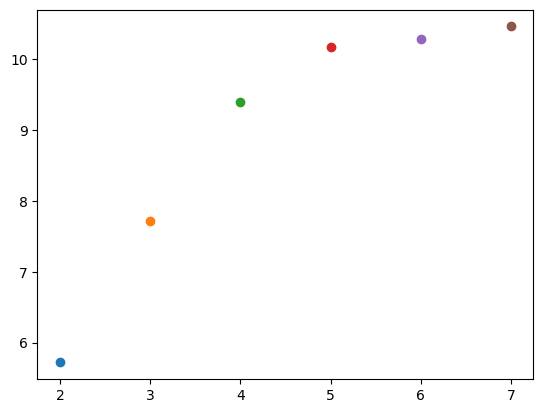

In [13]:
def x_error(f, g, h, a, b, dt, nt, ybegin=lambda t: 0, yend=lambda t: 0):
    for n in range(2, 8):
        x = np.linspace(a, b, (1 << n) + 1)[1:-1]
        t = np.linspace(0, dt * nt, nt + 1)
        y = method_of_lines(f, g, x, t, ybegin, yend)
        T, X = np.meshgrid(t, x)
        y_true = h(T, X)
        print(n, np.max(np.abs(y_true - y)))
        plt.scatter(-np.log2(x[1] - x[0]), -np.log2(np.max(np.abs(y_true - y))))

x_error(f, g, h, 0, 1, .001, 100)

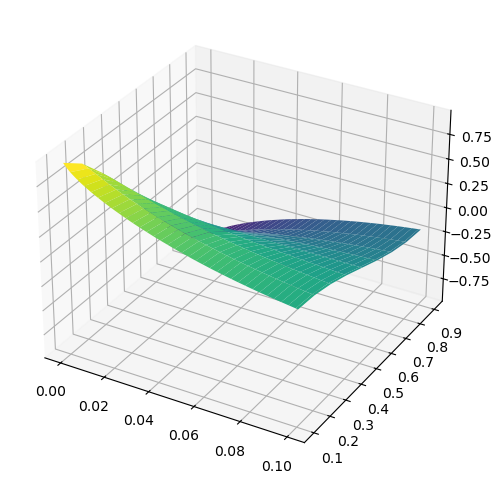

In [14]:
# (b)
def f(t, y, dx, dt, ybegin, yend):
    lam = 1 / dx ** 2
    n = len(y)
    A = -2 * np.eye(n) + np.diag(np.ones(n-1), -1) + np.diag(np.ones(n-1), 1)
    A[0, 1] = 2
    A[-1, -2] = 2
    return (lam * A) @ y


def g(x):
    return np.cos(np.pi * x)


x = np.linspace(0, 1, 11)[1:-1]
t = np.linspace(0, .001 * 100, 101)

y = method_of_lines(f, g, x, t)
plot_3d(t, x, y)

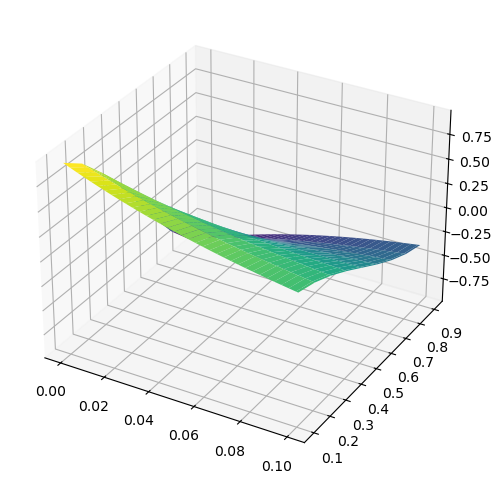

In [15]:
def h(t, x):
    return np.exp(- np.pi ** 2 * t) * np.cos(np.pi * x)

plot_3d(t, x, h)

2 0.2892794521086938
3 0.20961649439659574
4 0.11364833877292546
5 0.058429974334396506
6 0.029611911116609768
7 0.014961226030582031


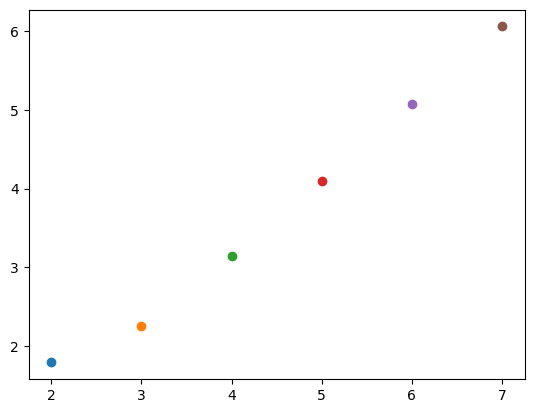

In [16]:
x_error(f, g, h, 0, 1, .001, 100)

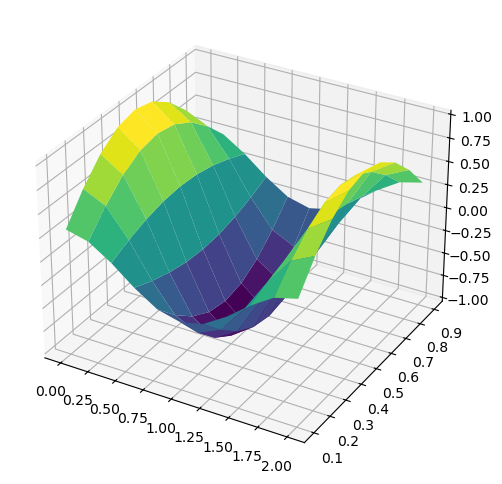

In [17]:
# 11.3
def f(t, y, dx, dt, ybegin, yend):
    lam = 1 / dx ** 2
    n = len(y) // 2
    A = np.vstack([
        np.hstack([
            np.zeros((n, n)), np.eye(n),
        ]),
        lam * np.hstack([
            -2 * np.eye(n) + np.diag(np.ones(n-1), -1) + np.diag(np.ones(n-1), 1), np.zeros((n, n)),
        ]),
    ])
    return A @ y


def g(x):
    return np.concatenate([np.sin(np.pi * x), np.zeros_like(x)])


x = np.linspace(0, 1, 11)[1:-1]
t = np.linspace(0, 2, 11)
y = method_of_lines(f, g, x, t)
plot_3d(t, x, y)

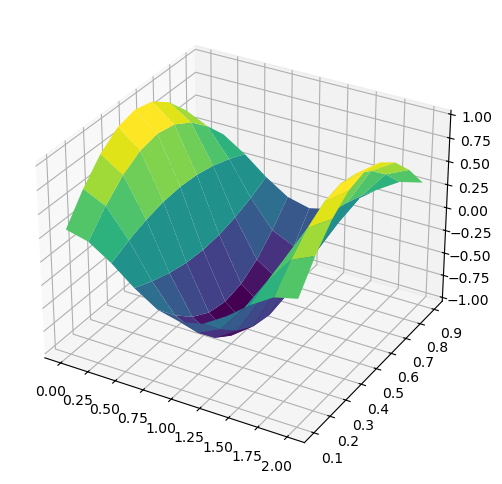

In [18]:
def h(t, x):
    return np.cos(np.pi * t) * np.sin(np.pi * x)

plot_3d(t, x, h)

2 0.0024453585842518777
3 0.0006205633914926345
4 0.00015565399459382956
5 3.887735695407013e-05
6 9.649120511601161e-06
7 2.3400750885915755e-06


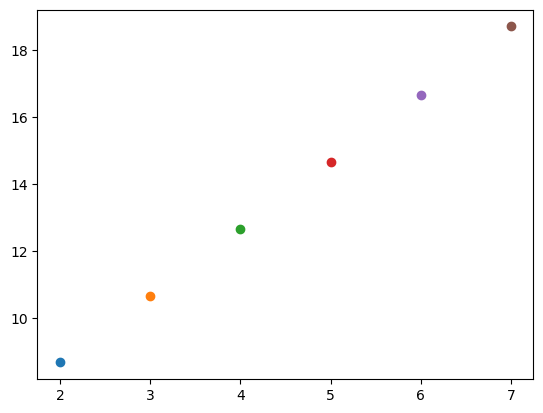

In [19]:
x_error(f, g, h, 0, 1, .001, 100)

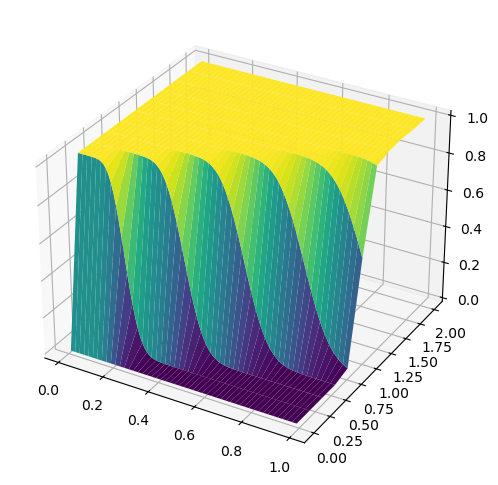

In [20]:
# 11.4
def f(t, y, dx, dt, ybegin, yend):
    lam = 1 / dx
    n = len(y)
    fy = (lam * (- np.eye(n) + np.diag(np.ones(n-1), -1))) @ y
    fy[0] += lam
    return fy


def g(x):
    return np.zeros_like(x)


x = np.linspace(0, 1, 101)[1:-1]
t = np.linspace(0, 2, 11)
y = method_of_lines(f, g, x, t)
plot_3d(x, t, y.T)

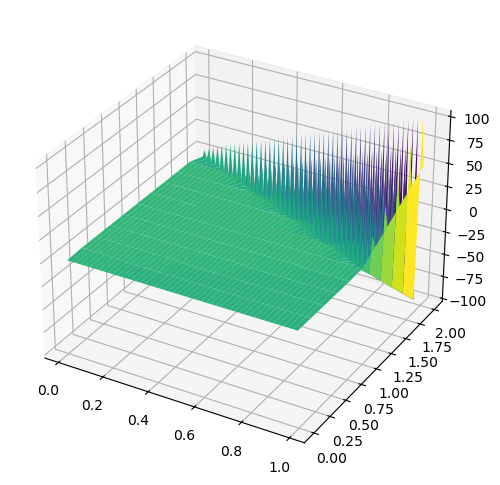

In [21]:
def f(t, y, dx, dt, ybegin, yend):
    lam = 1 / dx
    n = len(y)
    A = -lam / 2 * (np.diag(np.ones(n-1), 1) - np.diag(np.ones(n-1), -1))
    A[-2, -1], A[-1, -1] = lam, -lam
    fy = A @ y
    fy[0] += lam / 2
    return fy


y = method_of_lines(f, g, x, t)
plot_3d(x, t, y.T)

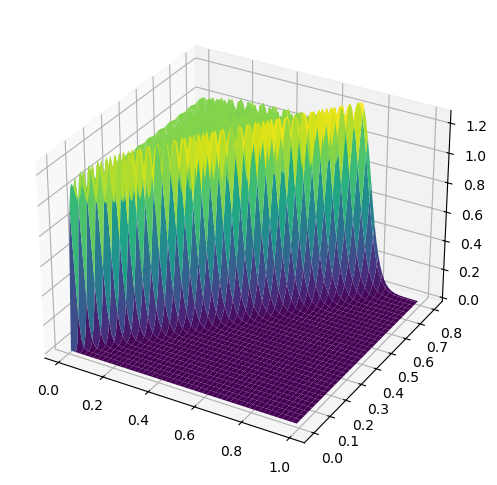

In [22]:
t = np.linspace(0, .8, 101)

y = method_of_lines(f, g, x, t)
plot_3d(x, t, y.T)

<Figure size 640x480 with 0 Axes>

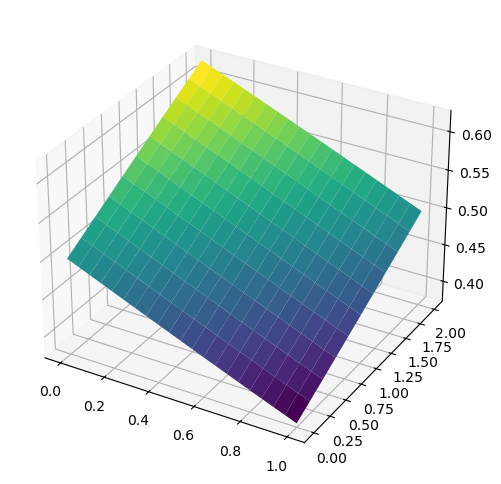

<Figure size 640x480 with 0 Axes>

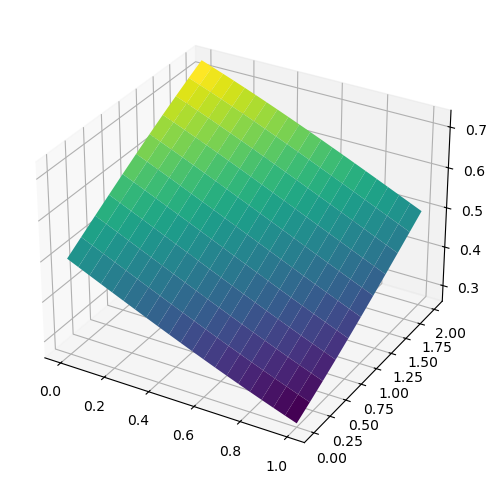

<Figure size 640x480 with 0 Axes>

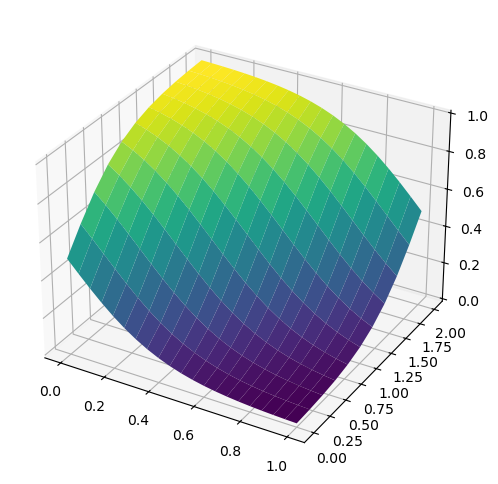

<Figure size 640x480 with 0 Axes>

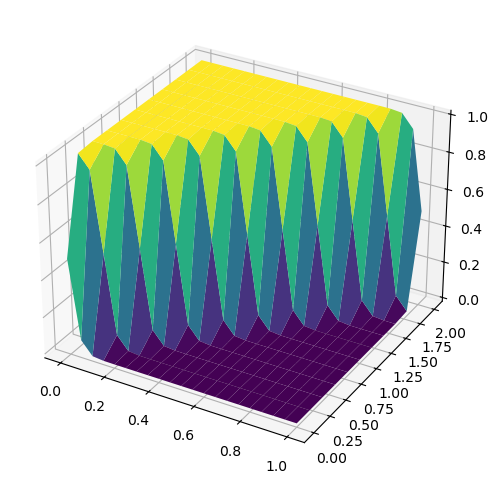

In [23]:
# 11.5
def h(t, x, v):
    return 1 / (1 + np.exp(x / (2 * v) - t / (4 * v)))


x = np.linspace(0, 1, 21)
t = np.linspace(0, 2, 11)
for v in 1, .5, .1, .01:
    plt.figure()
    plot_3d(x, t, lambda x, t: h(t, x, v))

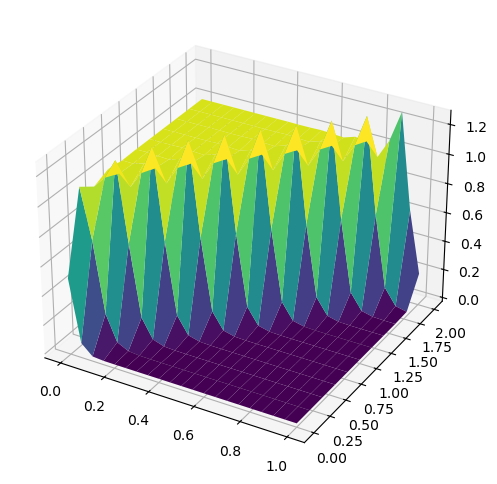

In [24]:
def f(t, y, dx, dt, ybegin, yend, v):
    y_plus, y_minus = shift_down(y), shift_up(y)
    fy = -y * (y_plus - y_minus) / 2 + v * (y_plus - 2 * y + y_minus) / dx
    fy /= dx
    fy[0] += (y[0] / 2 / dx + v / dx ** 2) * ybegin(t)
    fy[-1] += (-y[-1] / 2 / dx + v / dx ** 2) * yend(t)
    return fy


def g(x, v):
    return 1 / (1 + np.exp(x / (2 * v)))

v = .01
y = method_of_lines(partial(f, v=v), partial(g, v=v), x, t, ybegin=partial(h, x=0, v=v), yend=partial(h, x=1, v=v))
plot_3d(x, t, y.T)

2 0.9864219702417631
3 1.191552685612133
4 0.5494933625558374
5 0.14379098208434604
6 0.03282356975847822
7 0.008542849357008886


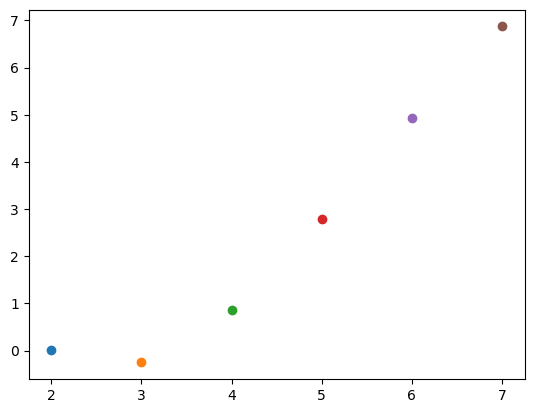

In [25]:
x_error(partial(f, v=v), partial(g, v=v), partial(h, v=v), 0, 1, .01, 200, ybegin=partial(h, x=0, v=v), yend=partial(h, x=1, v=v))

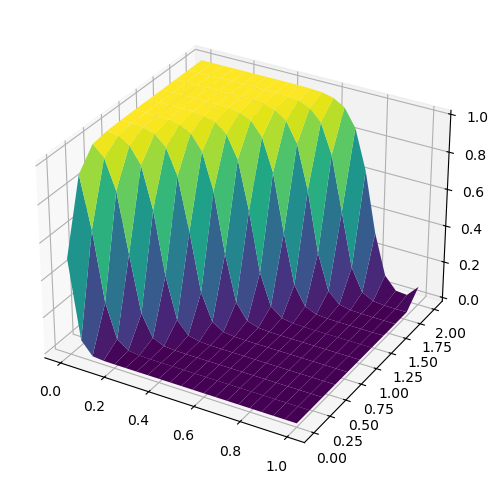

In [26]:
def f(t, y, dx, dt, ybegin, yend, v):
    y_plus, y_minus = shift_down(y), shift_up(y)
    yprime = np.where(y > 0, (y - y_minus) / dx, (y_plus - y) / dx)
    fy = -y * yprime + v * (y_plus - 2 * y + y_minus) / dx ** 2
    fy[0] += ((y[0] / dx + v / dx ** 2) if y[0] > 0 else v / dx ** 2) * ybegin(t)
    fy[-1] += v / dx ** 2 * yend(t)
    return fy

v = .01
y = method_of_lines(partial(f, v=v), partial(g, v=v), x, t, ybegin=partial(h, x=0, v=v), yend=partial(h, x=1, v=v))
plot_3d(x, t, y.T)

2 0.9612605455965383
3 0.975784842360933
4 0.9655548666125445
5 0.9027014350844673
6 0.7393458918687675
7 0.4989164655332606


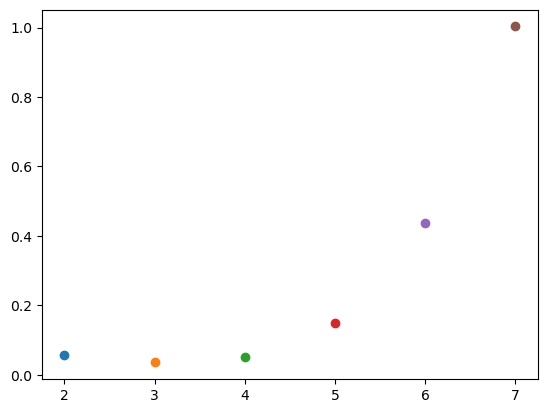

In [27]:
x_error(partial(f, v=v), partial(g, v=v), partial(h, v=v), 0, 1, .01, 200, ybegin=partial(h, x=0, v=v), yend=partial(h, x=1, v=v))

<Figure size 640x480 with 0 Axes>

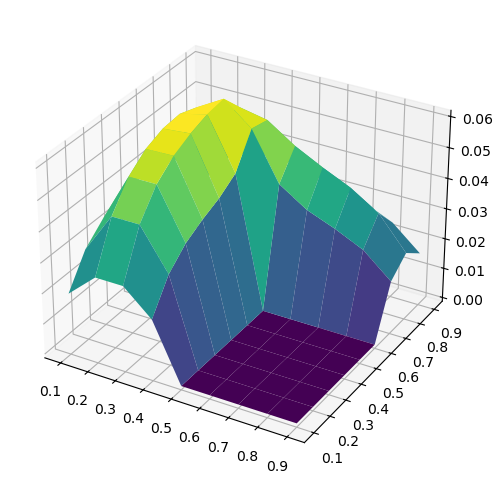

<Figure size 640x480 with 0 Axes>

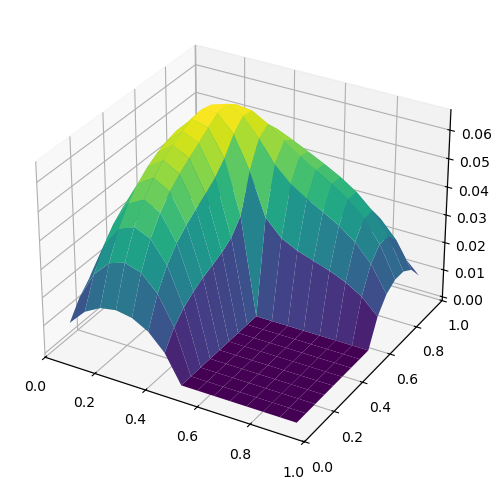

<Figure size 640x480 with 0 Axes>

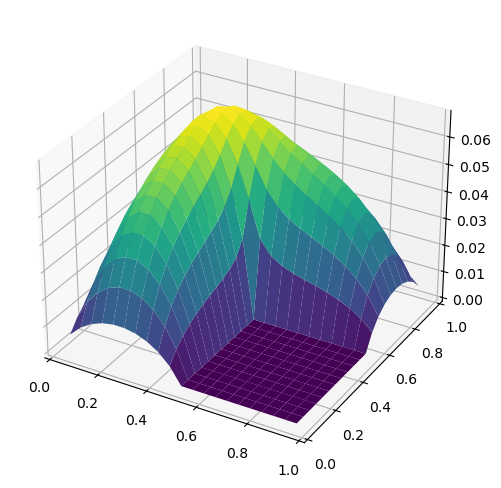

<Figure size 640x480 with 0 Axes>

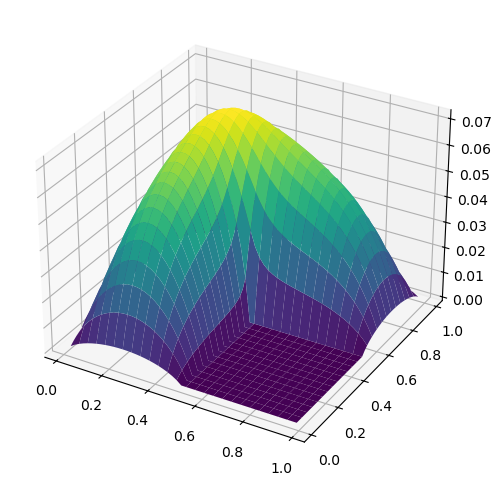

In [28]:
# 11.6
# (a)
def laplace(n, skip=lambda i, j: False):
    A = 4 * np.eye(n ** 2)
    for k in range(n ** 2):
        i, j = divmod(k, n)

        if not skip(i, j):
            if i - 1 >= 0:
                A[k, (i-1)*n + j] = -1
            if i + 1 < n:
                A[k, (i+1)*n + j] = -1
            if j - 1 >= 0:
                A[k, k - 1] = -1
            if j + 1 < n:
                A[k, k + 1] = -1
    return A


def skip(i, j, n):
    return i >= n // 2 and j <= (n+1) // 2


def generate_ab(n):
    b = 2 * np.ones(n ** 2)

    for i in range(n):
        for j in range(n):
            if skip(i, j, n):
                b[i*n + j] = 0
    
    A = laplace(n, skip=partial(skip, n=n))
    h = 1 / (n + 1)
    return A / h ** 2, b

for n in 9, 15, 21, 51:
    plt.figure()
    x = np.linspace(0, 1, n+2)[1:-1]
    y = np.linspace(0, 1, n+2)[1:-1]
    A, b = generate_ab(n)
    z = la.solve(A, b).reshape(n, n)
    plot_3d(y, x, z.T)

<Figure size 640x480 with 0 Axes>

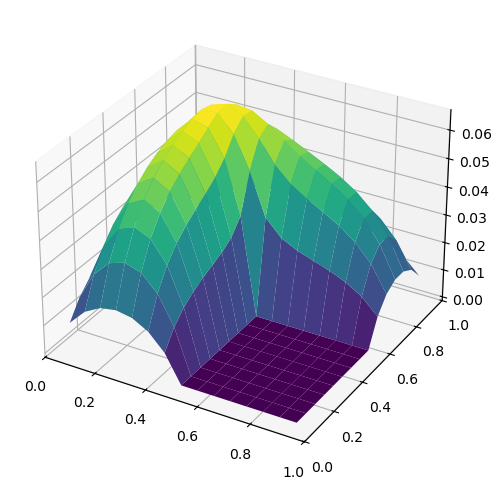

In [29]:
# (b)
for n in 15,:
    plt.figure()
    x = np.linspace(0, 1, n+2)[1:-1]
    y = np.linspace(0, 1, n+2)[1:-1]
    A, b = generate_ab(n)
    z = sor(A, b, np.zeros(n**2), tol=1e-10, n=100)[-1].reshape(n, n)
    plot_3d(y, x, z.T)

In [30]:
n = 31
h = 1 / (n + 1)
A = laplace(n) / h ** 2
np.array(sorted(la.eigvals(A) / np.pi ** 2)).round(2)[:10]


array([ 2.  +0.j,  4.99+0.j,  4.99+0.j,  7.97+0.j,  9.93+0.j,  9.93+0.j,
       12.92+0.j, 12.92+0.j, 16.79+0.j, 16.79+0.j])

[np.complex128(-9.549150281252622+0j), np.complex128(-34.54915028125268+0j), np.complex128(-65.45084971874735+0j), np.complex128(-90.45084971874735+0j)]
True
[np.complex128(-9.769795432682848+0j), np.complex128(-37.90080021472552+0j), np.complex128(-80.99999999999994+0j), np.complex128(-133.86899521795712+0j), np.complex128(-190.13100478204277+0j), np.complex128(-243.00000000000006+0j), np.complex128(-286.09919978527444+0j), np.complex128(-314.2302045673172+0j)]
True
[np.complex128(-9.841548382704723+0j), np.complex128(-39.03105140428232+0j), np.complex128(-86.57449554828298+0j), np.complex128(-150.852845846459+0j), np.complex128(-229.67718017278972+0j), np.complex128(-320.36323036116045+0j), np.complex128(-419.8227917383366+0j), np.complex128(-524.6688882302107+0j), np.complex128(-631.3311117697885+0j), np.complex128(-736.1772082616646+0j), np.complex128(-835.6367696388388+0j), np.complex128(-926.3228198272103+0j), np.complex128(-1005.1471541535409+0j), np.complex128(-1069.42550445171

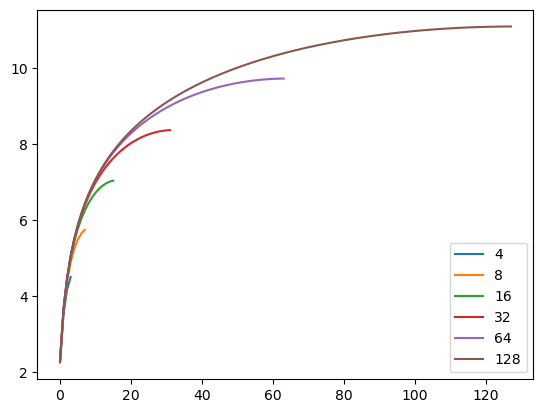

In [31]:
# 11.8
for exponent in range(2, 8):
    n = 1 << exponent
    h = 1 / (n + 1)
    A = -2 * np.eye(n) + np.diag(np.ones(n-1), -1) + np.diag(np.ones(n-1), 1)
    A /= h ** 2
    eigs = sorted(la.eigvals(A), reverse=True)
    print(eigs)
    print(all(-4 / h ** 2 < eig < 0 for eig in eigs))
    plt.plot(np.log(np.abs(eigs)), label=n)
plt.legend()


In [32]:
# 11.10
for n in 5, 10, 15:
    h = 1 / (n + 1)
    A = laplace(n) / h ** 2
    L, D, U= np.tril(A, -1), np.diag(np.diag(A)), np.triu(A, 1)
    ws = np.linspace(0, 2, 101)
    rhos = []
    for w in ws:
        G = la.solve(D + w * L, (1 - w) * D - w * U)
        rhos.append(np.abs(la.eigvals(G)).max())
    print(np.min(rhos), (1 - np.sin(np.pi * h)) / (1 + np.sin(np.pi * h)))


0.3400000000000006 0.3333333333333333
0.5758690521481928 0.5603879212747743
0.6800000000000065 0.6735136777159921


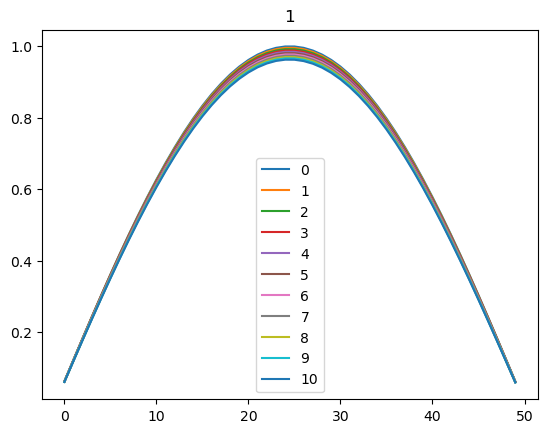

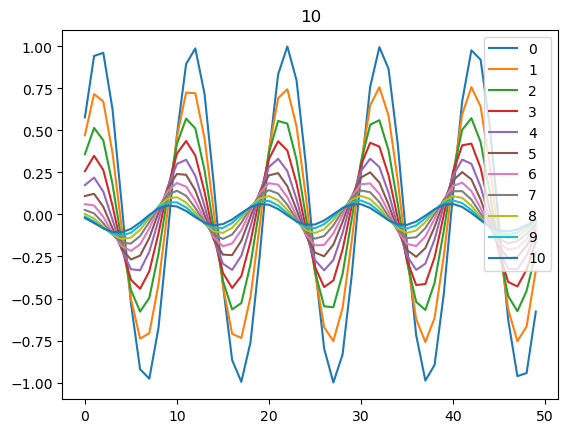

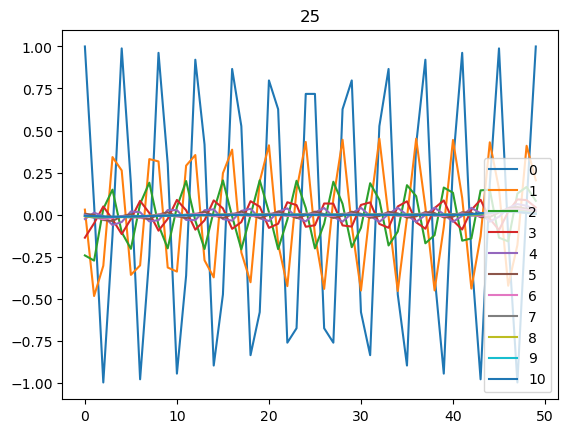

In [33]:
# 11.13
n = 50
A = 2 * np.eye(n) - np.diag(np.ones(n-1), 1) - np.diag(np.ones(n-1), -1)

for k in 1, 10, 25:
    plt.figure()
    x = [np.sin(j * k * np.pi / (n+1)) for j in range(1, n+1)]
    history = gauss_seidel(A, np.zeros(n), x, tol=1e-14, n=10)
    plt.plot(history.T, label=range(11))
    plt.legend()
    plt.title(k)

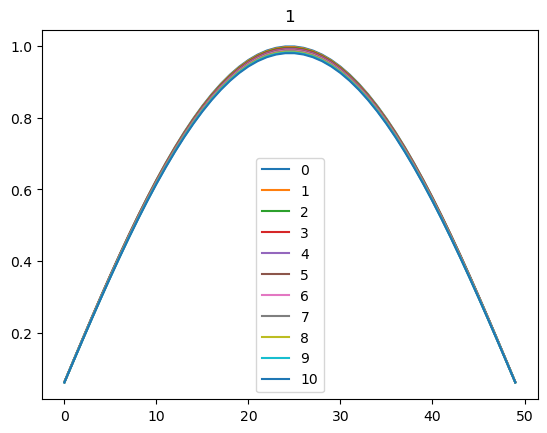

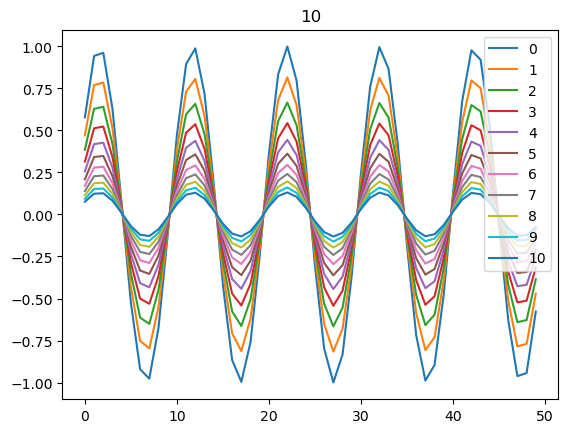

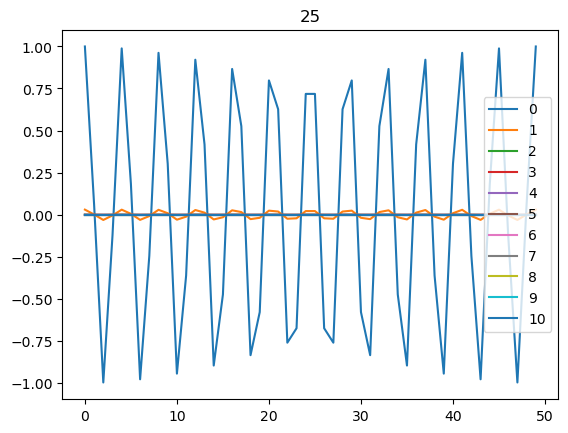

In [34]:
for k in 1, 10, 25:
    plt.figure()
    x = [np.sin(j * k * np.pi / (n+1)) for j in range(1, n+1)]
    history = jacobi(A, np.zeros(n), x, tol=1e-14, n=10)
    plt.plot(history.T, label=range(11))
    plt.legend()
    plt.title(k)

In [35]:
# 8.14
def coarse_to_fine(x, step):
    n = len(x)
    for i in range(step, n, 2 * step):
        if i + step < n:
            x[i] = (x[i-step] + x[i+step]) / 2
        else:
            x[i] = x[i-step]


def two_grid(A, b, x0, tol=1e-8, n=100):
    x = gauss_seidel(A, b, x0, tol, 5)[-1]

    for i in range(n):
        r = b - A @ x
        if la.norm(r) < tol:
            break
        xr = gauss_seidel(A, r, np.zeros_like(x0), tol, 5, step=2)[-1]
        coarse_to_fine(xr, step=1)

        x += xr
        x = gauss_seidel(A, b, x, tol, 5)[-1]
    # print(i)

    return x


def multi_grid_once(A, b, x0, basesize, tol=1e-8, step=1):
    n = len(x0)
    if n // step <= basesize:
        x0[::step] = la.solve(A[::step, ::step], x0[::step])
        return x0

    x = gauss_seidel(A, b, x0, tol, 5)[-1]

    r = b - A @ x
    xr = multi_grid_once(A, r, np.zeros_like(x0), basesize, tol=tol, step=2*step)
    coarse_to_fine(xr, step)

    x += xr
    x = gauss_seidel(A, b, x, tol, 5)[-1]
    return x


def multi_grid(A, b, x0, basesize=5, tol=1e-8, n=100):
    x = x0
    for i in range(n):
        x = multi_grid_once(A, b, x, basesize, tol)
        r = b - A @ x
        if la.norm(r) < tol:
            break
    # print(i)
    return x

# Uxx = 0, [0, 1] 1, 0
n = 15
A = 2 * np.eye(n) - np.diag(np.ones(n-1), -1) - np.diag(np.ones(n-1), 1)
b = np.zeros(n)
b[0] = 1
print(la.solve(A, b).round(3))
print(two_grid(A, b, np.linspace(0, 1, n+2)[-1:1:-1]).round(3))
print(multi_grid(A, b, np.linspace(0, 1, n+2)[-1:1:-1]).round(3))

[0.938 0.875 0.812 0.75  0.688 0.625 0.562 0.5   0.437 0.375 0.312 0.25
 0.188 0.125 0.062]
[0.938 0.875 0.813 0.75  0.688 0.625 0.563 0.5   0.438 0.375 0.313 0.25
 0.188 0.125 0.063]
[0.938 0.875 0.813 0.75  0.688 0.625 0.563 0.5   0.438 0.375 0.313 0.25
 0.188 0.125 0.063]


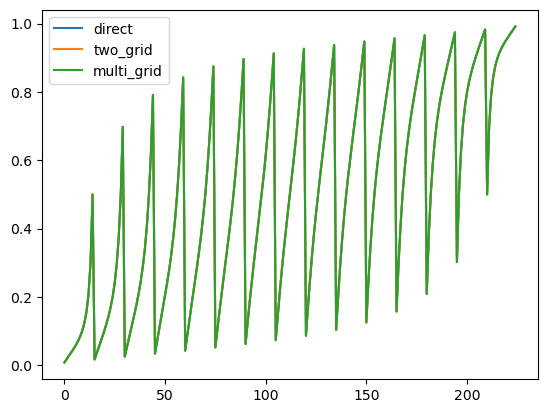

In [36]:
# Uxx + Uyy = 0, [0, 1] * [0, 1] left, bottom 0, upper right 1
A = laplace(n)
b = np.zeros(n ** 2)
for j in range(n):
    k = (n-1) * n + j
    b[k] += 1

for i in range(n):
    k = i * n + n-1
    b[k] += 1


plt.plot(la.solve(A, b), label='direct')
plt.plot(two_grid(A, b, np.zeros(n ** 2)), label='two_grid')
plt.plot(multi_grid(A, b, np.zeros(n ** 2), basesize=25), label='multi_grid')
plt.legend()